# 16 — Classificação com amostra de 5 M linhas

Réplica do notebook 15 com `SAMPLE_TRAIN = 5_000_000`.  
**Pré-requisito:** notebook 14 já gerou `ml_features.parquet`, `test_set.parquet` e `val_set.parquet`.

**Target:** `FAIXA_3C` — Baixo / Medio / Alto  
**Variantes:** M1 (28 feat) / M2 (+IDHM, 37) / M3 (+IDHM pessoal, 39)  
**Algoritmos:** LR · DT · RF · HGB · SVM · LGB · Ensemble SVM+LGB Hard · Soft · Top-2 · Full

## 0. Imports e configuração

In [1]:
import warnings, time, gc
warnings.filterwarnings('ignore')

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.linear_model  import LogisticRegression
from sklearn.svm           import LinearSVC
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (RandomForestClassifier,
                                   HistGradientBoostingClassifier,
                                   VotingClassifier)
from sklearn.pipeline      import Pipeline
from sklearn.impute        import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import (classification_report, accuracy_score,
                                   f1_score, ConfusionMatrixDisplay)
from sklearn.base          import clone
from pathlib import Path

BASE         = Path('../data/processed')
ML_PARQUET   = BASE / 'ml_features.parquet'
TEST_SET     = BASE / 'test_set.parquet'
VAL_SET      = BASE / 'val_set.parquet'
SEED         = 42
SAMPLE_TRAIN = 5_000_000          # ← única diferença em relação ao notebook 15
CLASS_3      = ['Baixo', 'Medio', 'Alto']

FEATS_M1 = [
    'REGIAO_NUM', 'TP_SEXO_NUM', 'TP_COR_RACA_NUM', 'TP_ESCOLA_NUM',
    'Q001_NUM', 'Q002_NUM', 'Q006_NUM',
    'Q_N_PESSOAS_NUM', 'Q_OCUP_PAI_NUM', 'Q_OCUP_MAE_NUM',
    'Q_EMPREGADA_NUM', 'Q_BANHEIRO_NUM', 'Q_QUARTO_NUM',
    'Q_CARRO_NUM', 'Q_MOTO_NUM', 'Q_GELADEIRA_NUM',
    'Q_FREEZER_NUM', 'Q_LAVADORA_NUM', 'Q_MICROONDAS_NUM', 'Q_IMPRESSORA_NUM',
    'Q_TV_NUM', 'Q_COMPUTADOR_NUM', 'Q_INTERNET_NUM', 'Q_CELULAR_NUM', 'Q_TEL_FIXO_NUM',
    'Q_TIPO_ESCOLA_EM_NUM', 'Q_BOLSA_FAM_NUM', 'Q_TRABALHA_NUM',
]
FEATS_IDHM = [
    'idhm', 'idhm_educacao', 'idhm_renda', 'idhm_longevidade',
    'renda_percapita', 'tx_analfabetismo', 'tx_envelhecimento',
    'esperanca_vida', 'mortalidade_infantil',
]
FEATS_PERS = ['idhm_cand_raca', 'idhm_cand_sexo']
FEATS_M2   = FEATS_M1 + FEATS_IDHM
FEATS_M3   = FEATS_M2 + FEATS_PERS
VARIANTS   = {'M1': FEATS_M1, 'M2': FEATS_M2, 'M3': FEATS_M3}

print(f'M1: {len(FEATS_M1)} | M2: {len(FEATS_M2)} | M3: {len(FEATS_M3)} features')
print(f'Amostra de treino: {SAMPLE_TRAIN:,}')

M1: 28 | M2: 37 | M3: 39 features
Amostra de treino: 5,000,000


## 1. Carregamento — 5 M amostras de treino

In [2]:
MAP_3C = {
    '<400': 'Baixo', '400-500': 'Baixo',
    '500-600': 'Medio', '600-700': 'Medio',
    '700-800': 'Alto', '>800': 'Alto',
}

df_val  = pd.read_parquet(VAL_SET)
df_test = pd.read_parquet(TEST_SET)
df_val['FAIXA_3C']  = df_val['FAIXA_MT'].map(MAP_3C)
df_test['FAIXA_3C'] = df_test['FAIXA_MT'].map(MAP_3C)

excl_ids = pd.concat([df_val[['_row_id']], df_test[['_row_id']]])

con = duckdb.connect()
con.execute("SET memory_limit = '12GB'")
con.register('excl_ids', excl_ids)

print(f'Carregando {SAMPLE_TRAIN:,} amostras de treino...')
t0 = time.time()
df_train = con.execute(f"""
    SELECT *
    FROM read_parquet('{ML_PARQUET}')
    WHERE FAIXA_MT IS NOT NULL
      AND NU_ANO BETWEEN 2019 AND 2024
      AND _row_id NOT IN (SELECT _row_id FROM excl_ids)
    USING SAMPLE {SAMPLE_TRAIN} (reservoir, {SEED})
""").df()
con.close()
print(f'Carregado em {time.time()-t0:.1f}s')

df_train['FAIXA_3C'] = df_train['FAIXA_MT'].map(MAP_3C)

print(f'Treino:  {len(df_train):>10,} linhas')
print(f'Val:     {len(df_val):>10,} linhas')
print(f'Teste:   {len(df_test):>10,} linhas (SELADO)')
print('\nDistribuição treino:')
print(df_train['FAIXA_3C'].value_counts(normalize=True).reindex(CLASS_3)
      .apply(lambda x: f'{x:.1%}'))

Carregando 5,000,000 amostras de treino...
Carregado em 1243.2s
Treino:   1,306,761 linhas
Val:      1,488,771 linhas
Teste:    1,654,191 linhas (SELADO)

Distribuição treino:
FAIXA_3C
Baixo    46.8%
Medio    44.3%
Alto      8.9%
Name: proportion, dtype: str


In [3]:
TARGET = 'FAIXA_3C'
arrays = {}
for vname, feats in VARIANTS.items():
    X_tr = df_train[feats].astype('float64').values
    X_v  = df_val[feats].astype('float64').values
    X_te = df_test[feats].astype('float64').values
    arrays[vname] = (X_tr, X_v, X_te)
    print(f'{vname}: {X_tr.shape}  NaN={np.isnan(X_tr).mean()*100:.1f}%')

y_train = df_train[TARGET].values
y_val   = df_val[TARGET].values
y_test  = df_test[TARGET].values

M1: (1306761, 28)  NaN=4.1%
M2: (1306761, 37)  NaN=20.5%
M3: (1306761, 39)  NaN=23.2%


## 2. Algoritmo Genético — otimização de hiperparâmetros

Mesmo AG do notebook 15. Subset de fitness = 50k (maior, pois temos mais dados).

In [4]:
GA_SUB  = 50_000    # subset maior para fitness (5M de treino disponíveis)
rng_sub = np.random.default_rng(SEED)

X_m1_tr  = arrays['M1'][0]
idx_sub  = rng_sub.choice(len(X_m1_tr), size=min(GA_SUB, len(X_m1_tr)), replace=False)
idx_subv = rng_sub.choice(len(arrays['M1'][1]), size=min(15_000, len(arrays['M1'][1])), replace=False)

X_sub,    y_sub    = X_m1_tr[idx_sub],          y_train[idx_sub]
X_subval, y_subval = arrays['M1'][1][idx_subv], y_val[idx_subv]

print(f'Subset treino AG: {len(X_sub):,} | Subset val AG: {len(X_subval):,}')

def _tournament(pop, fits, k, rng):
    idx = rng.integers(0, len(pop), k)
    return pop[idx[np.argmax(fits[idx])]].copy()

def _crossover(p1, p2, rng):
    mask = rng.random(len(p1)) < 0.5
    return np.where(mask, p1, p2), np.where(mask, p2, p1)

def _mutate(ind, gene_min, gene_max, binary_mask, rng):
    ind = ind.copy()
    ranges = gene_max - gene_min
    for i in range(len(ind)):
        if binary_mask[i]:
            if rng.random() < 0.30: ind[i] = 1.0 - ind[i]
        else:
            if rng.random() < 0.40:
                ind[i] = np.clip(ind[i] + rng.normal(0, 0.15 * ranges[i]),
                                 gene_min[i], gene_max[i])
    return ind

def evolve_ag(gene_min, gene_max, fitness_fn, binary_mask,
              pop_size=20, n_gens=15, seed=SEED, label=''):
    rng = np.random.default_rng(seed)
    pop = np.column_stack([rng.uniform(gene_min[i], gene_max[i], pop_size)
                           for i in range(len(gene_min))])
    for i, b in enumerate(binary_mask):
        if b: pop[:, i] = np.round(pop[:, i])
    fits = np.array([fitness_fn(ind) for ind in pop])
    hist = [fits.max()]
    print(f'[{label}] Gen  0  best={fits.max():.4f}  mean={fits.mean():.4f}')
    for gen in range(1, n_gens + 1):
        elite   = list(pop[np.argsort(fits)[-2:]])
        new_pop = elite[:]
        while len(new_pop) < pop_size:
            p1 = _tournament(pop, fits, 3, rng)
            p2 = _tournament(pop, fits, 3, rng)
            c1, c2 = (_crossover(p1, p2, rng) if rng.random() < 0.70
                      else (p1.copy(), p2.copy()))
            if rng.random() < 0.25: c1 = _mutate(c1, gene_min, gene_max, binary_mask, rng)
            if rng.random() < 0.25: c2 = _mutate(c2, gene_min, gene_max, binary_mask, rng)
            new_pop.append(c1)
            if len(new_pop) < pop_size: new_pop.append(c2)
        pop  = np.array(new_pop)
        fits = np.array([fitness_fn(ind) for ind in pop])
        hist.append(fits.max())
        print(f'[{label}] Gen {gen:2d}  best={fits.max():.4f}  mean={fits.mean():.4f}')
    return pop[fits.argmax()], fits.max(), hist

print('Componentes do AG definidos.')

Subset treino AG: 50,000 | Subset val AG: 15,000
Componentes do AG definidos.


In [5]:
def decode_lr(ind):
    return float(10 ** np.clip(ind[0], -3, 2)), bool(round(np.clip(ind[1], 0, 1)))

def fitness_lr(ind):
    C, bal = decode_lr(ind)
    try:
        m = Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler()),
                      ('clf', LogisticRegression(C=C, class_weight='balanced' if bal else None,
                                                 max_iter=300, solver='saga', n_jobs=-1, random_state=SEED))])
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro', labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — Logistic Regression ===')
t0 = time.time()
best_lr_ind, _, ag_hist_lr = evolve_ag(
    np.array([-3.0, 0.0]), np.array([2.0, 1.0]),
    fitness_lr, binary_mask=[False, True], pop_size=20, n_gens=15, label='LR')
best_C_lr, best_bal_lr = decode_lr(best_lr_ind)
print(f'\nResultado: C={best_C_lr:.4f}, balanced={best_bal_lr}  ({(time.time()-t0)/60:.1f} min)')

=== AG — Logistic Regression ===
[LR] Gen  0  best=0.4411  mean=0.4312
[LR] Gen  1  best=0.4411  mean=0.4384
[LR] Gen  2  best=0.4411  mean=0.4376
[LR] Gen  3  best=0.4411  mean=0.4384
[LR] Gen  4  best=0.4411  mean=0.4376
[LR] Gen  5  best=0.4413  mean=0.4411
[LR] Gen  6  best=0.4416  mean=0.4411
[LR] Gen  7  best=0.4416  mean=0.4395
[LR] Gen  8  best=0.4416  mean=0.4405
[LR] Gen  9  best=0.4416  mean=0.4414
[LR] Gen 10  best=0.4419  mean=0.4407
[LR] Gen 11  best=0.4419  mean=0.4397
[LR] Gen 12  best=0.4419  mean=0.4407
[LR] Gen 13  best=0.4419  mean=0.4418
[LR] Gen 14  best=0.4419  mean=0.4419
[LR] Gen 15  best=0.4419  mean=0.4418

Resultado: C=0.0010, balanced=True  (6.2 min)


In [6]:
def decode_svm(ind):
    return float(10 ** np.clip(ind[0], -3, 2)), bool(round(np.clip(ind[1], 0, 1)))

def fitness_svm(ind):
    C, bal = decode_svm(ind)
    try:
        m = Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler()),
                      ('clf', LinearSVC(C=C, class_weight='balanced' if bal else None,
                                        max_iter=2000, random_state=SEED))])
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro', labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — SVM (LinearSVC) ===')
t0 = time.time()
best_svm_ind, _, ag_hist_svm = evolve_ag(
    np.array([-3.0, 0.0]), np.array([2.0, 1.0]),
    fitness_svm, binary_mask=[False, True], pop_size=20, n_gens=15, label='SVM')
best_C_svm, best_bal_svm = decode_svm(best_svm_ind)
print(f'\nResultado: C={best_C_svm:.4f}, balanced={best_bal_svm}  ({(time.time()-t0)/60:.1f} min)')

=== AG — SVM (LinearSVC) ===
[SVM] Gen  0  best=0.4815  mean=0.4339
[SVM] Gen  1  best=0.4815  mean=0.4696
[SVM] Gen  2  best=0.4815  mean=0.4657
[SVM] Gen  3  best=0.4815  mean=0.4696
[SVM] Gen  4  best=0.4815  mean=0.4657
[SVM] Gen  5  best=0.4815  mean=0.4815
[SVM] Gen  6  best=0.4815  mean=0.4815
[SVM] Gen  7  best=0.4815  mean=0.4736
[SVM] Gen  8  best=0.4815  mean=0.4776
[SVM] Gen  9  best=0.4815  mean=0.4815
[SVM] Gen 10  best=0.4815  mean=0.4776
[SVM] Gen 11  best=0.4815  mean=0.4736
[SVM] Gen 12  best=0.4815  mean=0.4776
[SVM] Gen 13  best=0.4815  mean=0.4815
[SVM] Gen 14  best=0.4815  mean=0.4815
[SVM] Gen 15  best=0.4815  mean=0.4815

Resultado: C=0.0714, balanced=True  (4.3 min)


In [7]:
def decode_lgb(ind):
    return float(np.clip(ind[0], 0.01, 0.30)), int(round(np.clip(ind[1], 15, 127)))

def fitness_lgb(ind):
    lr, nl = decode_lgb(ind)
    try:
        m = lgb.LGBMClassifier(learning_rate=lr, num_leaves=nl,
                                n_estimators=200, max_depth=8,
                                n_jobs=-1, random_state=SEED, verbose=-1)
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro', labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — LightGBM ===')
t0 = time.time()
best_lgb_ind, _, ag_hist_lgb = evolve_ag(
    np.array([0.01, 15.0]), np.array([0.30, 127.0]),
    fitness_lgb, binary_mask=[False, False], pop_size=15, n_gens=10, label='LGB')
best_lr_lgb, best_nl_lgb = decode_lgb(best_lgb_ind)
print(f'\nResultado: lr={best_lr_lgb:.4f}, num_leaves={best_nl_lgb}  ({(time.time()-t0)/60:.1f} min)')

=== AG — LightGBM ===
[LGB] Gen  0  best=0.4657  mean=0.4569
[LGB] Gen  1  best=0.4657  mean=0.4598
[LGB] Gen  2  best=0.4657  mean=0.4629
[LGB] Gen  3  best=0.4657  mean=0.4647
[LGB] Gen  4  best=0.4657  mean=0.4651
[LGB] Gen  5  best=0.4657  mean=0.4638
[LGB] Gen  6  best=0.4657  mean=0.4650
[LGB] Gen  7  best=0.4657  mean=0.4644
[LGB] Gen  8  best=0.4657  mean=0.4645
[LGB] Gen  9  best=0.4657  mean=0.4630
[LGB] Gen 10  best=0.4657  mean=0.4646

Resultado: lr=0.1406, num_leaves=102  (6.7 min)


In [8]:
def decode_hgb(ind):
    return float(np.clip(ind[0], 0.01, 0.30)), int(round(np.clip(ind[1], 3, 12)))

def fitness_hgb(ind):
    lr, md = decode_hgb(ind)
    try:
        m = HistGradientBoostingClassifier(learning_rate=lr, max_depth=md,
                                           max_iter=200, min_samples_leaf=50, random_state=SEED)
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro', labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — HistGradientBoosting ===')
t0 = time.time()
best_hgb_ind, _, ag_hist_hgb = evolve_ag(
    np.array([0.01, 3.0]), np.array([0.30, 12.0]),
    fitness_hgb, binary_mask=[False, False], pop_size=15, n_gens=10, label='HGB')
best_lr_hgb, best_md_hgb = decode_hgb(best_hgb_ind)
print(f'\nResultado: lr={best_lr_hgb:.4f}, max_depth={best_md_hgb}  ({(time.time()-t0)/60:.1f} min)')

=== AG — HistGradientBoosting ===
[HGB] Gen  0  best=0.4628  mean=0.4557
[HGB] Gen  1  best=0.4643  mean=0.4590
[HGB] Gen  2  best=0.4690  mean=0.4630
[HGB] Gen  3  best=0.4690  mean=0.4652
[HGB] Gen  4  best=0.4690  mean=0.4662
[HGB] Gen  5  best=0.4690  mean=0.4674
[HGB] Gen  6  best=0.4690  mean=0.4684
[HGB] Gen  7  best=0.4690  mean=0.4685
[HGB] Gen  8  best=0.4701  mean=0.4685
[HGB] Gen  9  best=0.4701  mean=0.4682
[HGB] Gen 10  best=0.4701  mean=0.4689

Resultado: lr=0.2999, max_depth=11  (1.7 min)


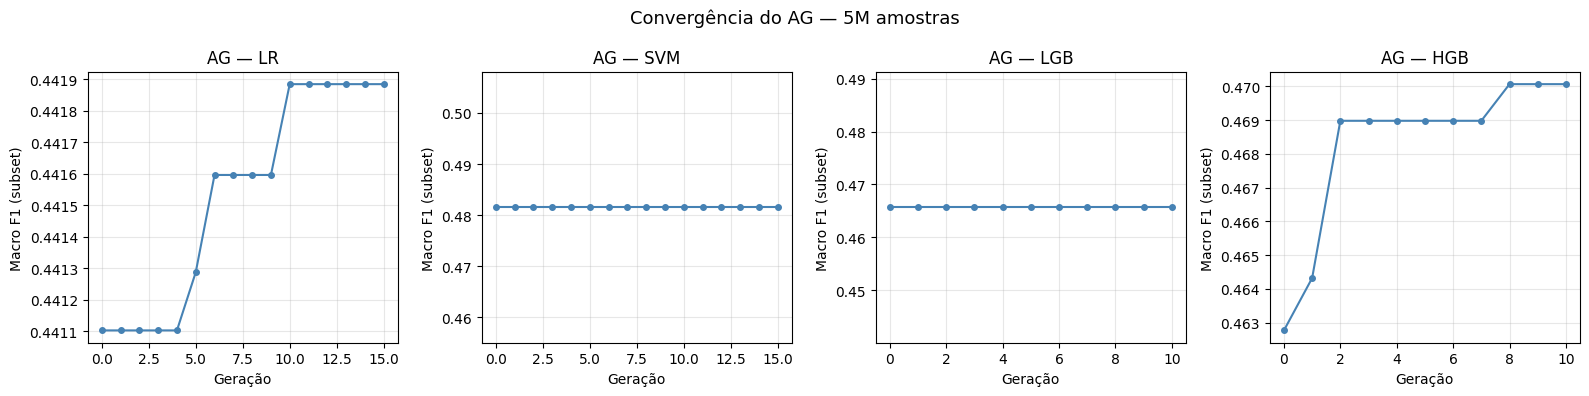

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for ax, (nome, hist) in zip(axes, [
    ('LR', ag_hist_lr), ('SVM', ag_hist_svm),
    ('LGB', ag_hist_lgb), ('HGB', ag_hist_hgb)
]):
    ax.plot(range(len(hist)), hist, 'o-', color='steelblue', markersize=4)
    ax.set_title(f'AG — {nome}')
    ax.set_xlabel('Geração')
    ax.set_ylabel('Macro F1 (subset)')
    ax.grid(True, alpha=0.3)
plt.suptitle('Convergência do AG — 5M amostras', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/ag_convergencia_5m.png', dpi=120)
plt.show()

## 3. Modelos com hiperparâmetros do AG

In [10]:
_imp = lambda: SimpleImputer(strategy='median')
_scl = lambda: StandardScaler()

modelos_base = {
    'LogisticRegression': Pipeline([
        ('imp', _imp()), ('scl', _scl()),
        ('clf', LogisticRegression(C=best_C_lr,
            class_weight='balanced' if best_bal_lr else None,
            max_iter=500, solver='saga', n_jobs=-1, random_state=SEED)),
    ]),
    'DecisionTree': Pipeline([
        ('imp', _imp()),
        ('clf', DecisionTreeClassifier(max_depth=12, min_samples_leaf=50, random_state=SEED)),
    ]),
    'RandomForest': Pipeline([
        ('imp', _imp()),
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=15,
                                       min_samples_leaf=50, n_jobs=-1, random_state=SEED)),
    ]),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=best_lr_hgb, max_depth=best_md_hgb,
        max_iter=200, min_samples_leaf=50, random_state=SEED),
    'SVM (LinearSVC)': Pipeline([
        ('imp', _imp()), ('scl', _scl()),
        ('clf', LinearSVC(C=best_C_svm,
            class_weight='balanced' if best_bal_svm else None,
            max_iter=3000, random_state=SEED)),
    ]),
    'LightGBM': lgb.LGBMClassifier(
        learning_rate=best_lr_lgb, num_leaves=best_nl_lgb,
        n_estimators=300, max_depth=8, n_jobs=-1, random_state=SEED, verbose=-1),
}

def make_cal_svm():
    return Pipeline([('imp', _imp()), ('scl', _scl()),
                     ('clf', CalibratedClassifierCV(
                         LinearSVC(C=best_C_svm,
                                   class_weight='balanced' if best_bal_svm else None,
                                   max_iter=3000, random_state=SEED), cv=3))])

def make_lgb_clone():
    return lgb.LGBMClassifier(learning_rate=best_lr_lgb, num_leaves=best_nl_lgb,
                               n_estimators=300, max_depth=8, n_jobs=-1,
                               random_state=SEED, verbose=-1)

def make_rf_clone():
    return Pipeline([('imp', _imp()),
                     ('clf', RandomForestClassifier(n_estimators=100, max_depth=15,
                                                    min_samples_leaf=50, n_jobs=-1,
                                                    random_state=SEED))])

def make_hgb_clone():
    return HistGradientBoostingClassifier(learning_rate=best_lr_hgb, max_depth=best_md_hgb,
                                          max_iter=200, min_samples_leaf=50, random_state=SEED)

ensembles_fixos = {
    'Ensemble SVM+LGB Hard': VotingClassifier(
        estimators=[('svm', make_cal_svm()), ('lgb', make_lgb_clone())],
        voting='hard', n_jobs=1),
    'Ensemble SVM+LGB Soft': VotingClassifier(
        estimators=[('svm', make_cal_svm()), ('lgb', make_lgb_clone())],
        voting='soft', n_jobs=1),
    'Ensemble Full Soft': VotingClassifier(
        estimators=[('svm', make_cal_svm()), ('lgb', make_lgb_clone()),
                    ('rf',  make_rf_clone()), ('hgb', make_hgb_clone())],
        voting='soft', n_jobs=1),
}

print(f'Base: {list(modelos_base.keys())}')
print(f'Ensembles fixos: {list(ensembles_fixos.keys())}')

Base: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'HistGradientBoosting', 'SVM (LinearSVC)', 'LightGBM']
Ensembles fixos: ['Ensemble SVM+LGB Hard', 'Ensemble SVM+LGB Soft', 'Ensemble Full Soft']


## 4. Loop de treinamento × M1 / M2 / M3

In [11]:
all_results   = []
all_trained   = {}
top2_ensemble = None
top2_names    = None

for vname, feats in VARIANTS.items():
    X_tr, X_v, X_te = arrays[vname]
    print(f'\n{"="*60}')
    print(f'  Variante {vname} — {len(feats)} features')
    print(f'{"="*60}')

    modelos_v = {n: clone(m) for n, m in modelos_base.items()}
    modelos_v.update({n: clone(m) for n, m in ensembles_fixos.items()})
    if top2_ensemble is not None:
        modelos_v['Ensemble Top-2 Soft'] = clone(top2_ensemble)

    f1_scores_v = {}
    for nome, modelo in modelos_v.items():
        print(f'  {nome}...', end=' ', flush=True)
        t0 = time.time()
        modelo.fit(X_tr, y_train)
        t_tr = time.time() - t0

        y_pred = modelo.predict(X_v)
        acc  = accuracy_score(y_val, y_pred)
        f1_w = f1_score(y_val, y_pred, average='weighted', labels=CLASS_3, zero_division=0)
        f1_m = f1_score(y_val, y_pred, average='macro',    labels=CLASS_3, zero_division=0)

        all_results.append({'Variante': vname, 'Modelo': nome,
                            'Acurácia': acc, 'F1 Weighted': f1_w,
                            'F1 Macro': f1_m, 'Tempo (s)': round(t_tr, 1)})
        all_trained[(nome, vname)] = modelo
        f1_scores_v[nome] = f1_m
        print(f'acc={acc:.3f}  F1m={f1_m:.3f}  F1w={f1_w:.3f}  ({t_tr:.0f}s)')

    if vname == 'M1' and top2_ensemble is None:
        base_f1    = {n: f1_scores_v[n] for n in modelos_base.keys()}
        top2_names = sorted(base_f1, key=base_f1.get, reverse=True)[:2]
        print(f'\nTop-2: {top2_names}')
        def _wrap(name):
            return make_cal_svm() if 'SVM' in name else clone(modelos_base[name])
        top2_ensemble = VotingClassifier(
            estimators=[(n.replace(' ','_').replace('(','').replace(')',''), _wrap(n))
                        for n in top2_names],
            voting='soft', n_jobs=1)

df_res = pd.DataFrame(all_results)
print('\n=== RESUMO ===')
pivot = df_res.pivot_table(index='Modelo', columns='Variante', values='F1 Macro', aggfunc='first')
print(pivot.round(4).to_string())


  Variante M1 — 28 features
  LogisticRegression... acc=0.483  F1m=0.438  F1w=0.485  (30s)
  DecisionTree... acc=0.584  F1m=0.450  F1w=0.566  (15s)
  RandomForest... acc=0.591  F1m=0.440  F1w=0.569  (70s)
  HistGradientBoosting... acc=0.594  F1m=0.468  F1w=0.578  (14s)
  SVM (LinearSVC)... acc=0.555  F1m=0.487  F1w=0.552  (23s)
  LightGBM... acc=0.594  F1m=0.469  F1w=0.578  (48s)
  Ensemble SVM+LGB Hard... acc=0.588  F1m=0.462  F1w=0.567  (82s)
  Ensemble SVM+LGB Soft... acc=0.592  F1m=0.442  F1w=0.570  (82s)
  Ensemble Full Soft... acc=0.593  F1m=0.447  F1w=0.572  (161s)

Top-2: ['SVM (LinearSVC)', 'LightGBM']

  Variante M2 — 37 features
  LogisticRegression... acc=0.485  F1m=0.441  F1w=0.487  (32s)
  DecisionTree... acc=0.586  F1m=0.451  F1w=0.567  (18s)
  RandomForest... acc=0.593  F1m=0.440  F1w=0.571  (81s)
  HistGradientBoosting... acc=0.597  F1m=0.473  F1w=0.581  (19s)
  SVM (LinearSVC)... acc=0.555  F1m=0.489  F1w=0.552  (74s)
  LightGBM... acc=0.597  F1m=0.473  F1w=0.581  (5

## 5. Resultados — comparação com notebook 15 (1 M)

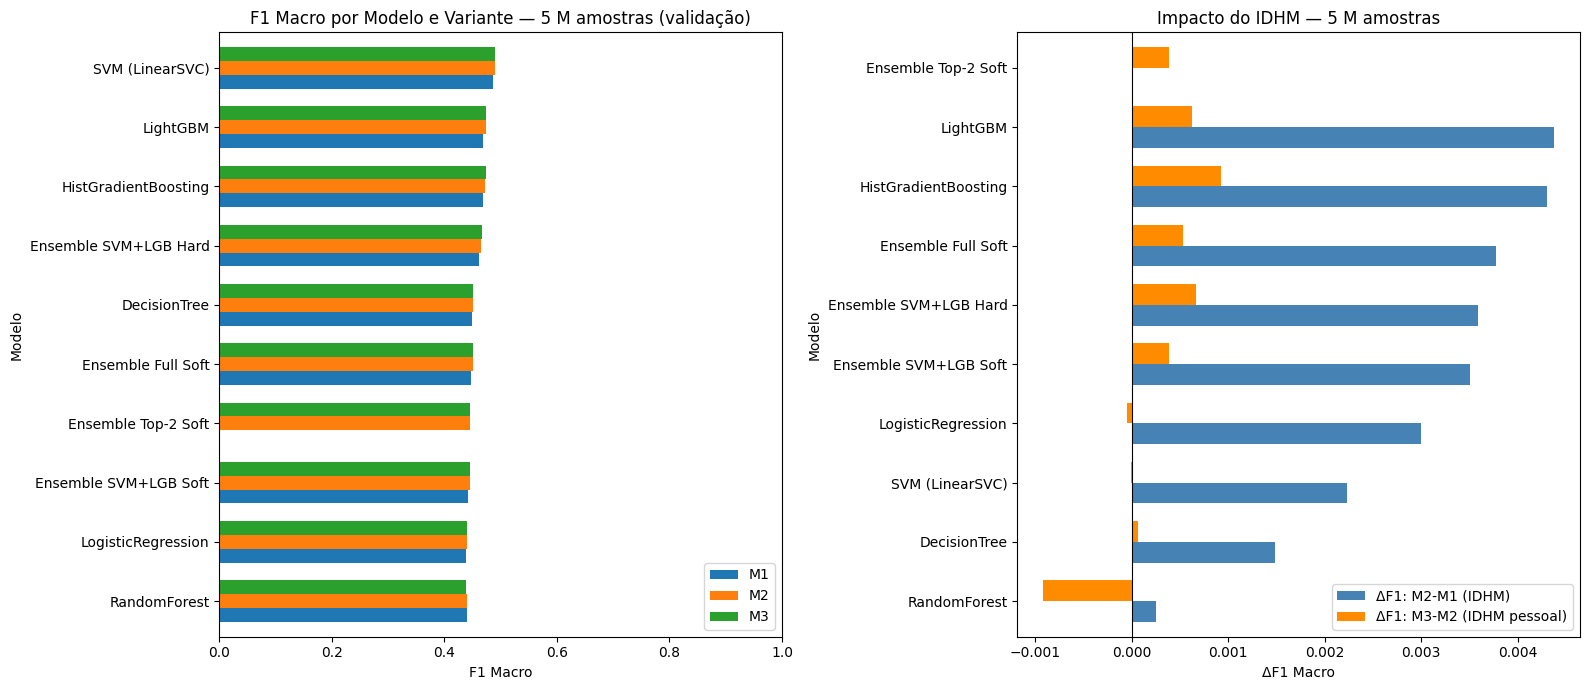


Top-5 por F1 Macro (validação):
Variante               Modelo  F1 Macro  F1 Weighted  Acurácia
      M2      SVM (LinearSVC)  0.489356     0.552127  0.554747
      M3      SVM (LinearSVC)  0.489352     0.552339  0.555001
      M1      SVM (LinearSVC)  0.487120     0.551868  0.554676
      M3             LightGBM  0.473954     0.581190  0.596868
      M3 HistGradientBoosting  0.473671     0.580997  0.596696


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
pivot_sorted = pivot.loc[pivot.mean(axis=1).sort_values(ascending=True).index]
pivot_sorted.plot(kind='barh', ax=ax, width=0.7)
ax.set_xlabel('F1 Macro')
ax.set_title('F1 Macro por Modelo e Variante — 5 M amostras (validação)')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)

ax2 = axes[1]
if all(v in pivot.columns for v in ['M1', 'M2', 'M3']):
    delta = pd.DataFrame({
        'ΔF1: M2-M1 (IDHM)':       pivot['M2'] - pivot['M1'],
        'ΔF1: M3-M2 (IDHM pessoal)': pivot['M3'] - pivot['M2'],
    }).sort_values('ΔF1: M2-M1 (IDHM)')
    delta.plot(kind='barh', ax=ax2, width=0.7, color=['steelblue', 'darkorange'])
    ax2.axvline(0, color='k', linewidth=0.8)
    ax2.set_xlabel('ΔF1 Macro')
    ax2.set_title('Impacto do IDHM — 5 M amostras')
    ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../data/processed/classificacao_resultados_5m.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop-5 por F1 Macro (validação):')
print(df_res.nlargest(5, 'F1 Macro')[['Variante','Modelo','F1 Macro','F1 Weighted','Acurácia']].to_string(index=False))

## 6. Relatório detalhado do melhor modelo

Melhor modelo: SVM (LinearSVC) (M2)

              precision    recall  f1-score   support

       Baixo       0.62      0.69      0.65    696506
       Medio       0.55      0.45      0.49    658941
        Alto       0.29      0.36      0.32    133324

    accuracy                           0.55   1488771
   macro avg       0.48      0.50      0.49   1488771
weighted avg       0.56      0.55      0.55   1488771



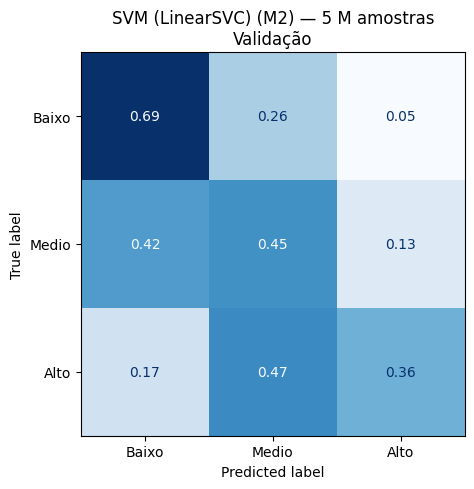

In [13]:
best_row   = df_res.loc[df_res['F1 Macro'].idxmax()]
best_nome  = best_row['Modelo']
best_var   = best_row['Variante']
best_model = all_trained[(best_nome, best_var)]

X_v_best    = arrays[best_var][1]
y_pred_best = best_model.predict(X_v_best)

print(f'Melhor modelo: {best_nome} ({best_var})\n')
print(classification_report(y_val, y_pred_best, labels=CLASS_3, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_best, labels=CLASS_3,
    normalize='true', cmap='Blues', ax=ax, colorbar=False, values_format='.2f')
ax.set_title(f'{best_nome} ({best_var}) — 5 M amostras\nValidação')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_5m_best.png', dpi=120)
plt.show()

## 6b. Matrizes de Confusão — todos os modelos (melhor variante)

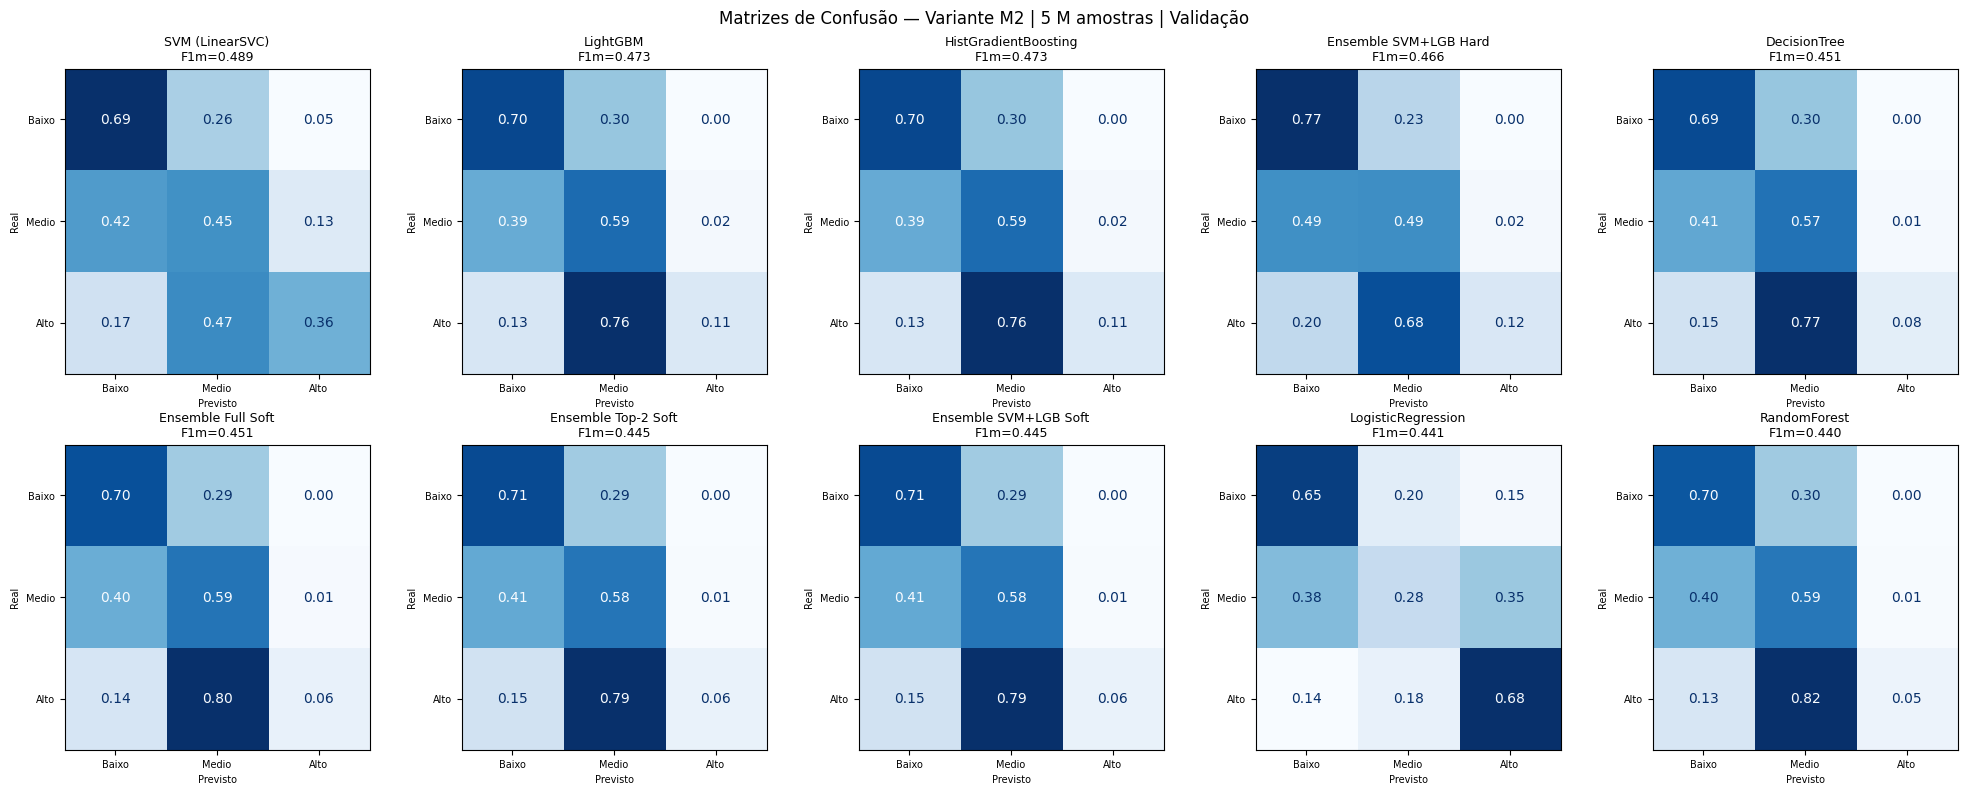

In [14]:
modelos_ordem = df_res[df_res['Variante'] == best_var].sort_values('F1 Macro', ascending=False)['Modelo'].tolist()
n_mod  = len(modelos_ordem)
n_cols = 5
n_rows = (n_mod + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.ravel()

for idx, nome in enumerate(modelos_ordem):
    ax = axes[idx]
    m  = all_trained.get((nome, best_var))
    if m is None: ax.set_visible(False); continue
    yp  = m.predict(arrays[best_var][1])
    f1m = f1_score(y_val, yp, average='macro', labels=CLASS_3, zero_division=0)
    ConfusionMatrixDisplay.from_predictions(
        y_val, yp, labels=CLASS_3,
        normalize='true', cmap='Blues', ax=ax, colorbar=False, values_format='.2f')
    ax.set_title(f'{nome}\nF1m={f1m:.3f}', fontsize=9)
    ax.tick_params(axis='both', labelsize=7)
    ax.set_xlabel('Previsto', fontsize=7)
    ax.set_ylabel('Real', fontsize=7)

for ax in axes[n_mod:]: ax.set_visible(False)

plt.suptitle(f'Matrizes de Confusão — Variante {best_var} | 5 M amostras | Validação', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrices_5m_todos.png', dpi=120, bbox_inches='tight')
plt.show()

## 6c. Matrizes de Confusão — melhor modelo × M1 / M2 / M3

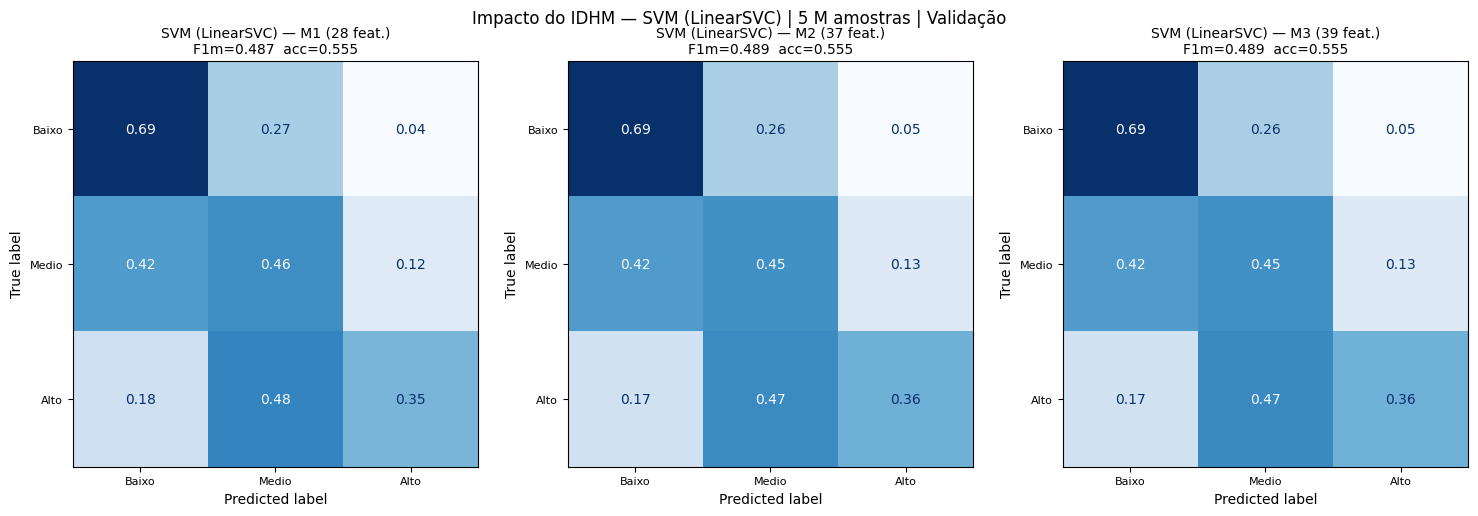

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, vname in zip(axes, ['M1', 'M2', 'M3']):
    m = all_trained.get((best_nome, vname))
    if m is None: ax.set_visible(False); continue
    yp  = m.predict(arrays[vname][1])
    f1m = f1_score(y_val, yp, average='macro', labels=CLASS_3, zero_division=0)
    acc = accuracy_score(y_val, yp)
    ConfusionMatrixDisplay.from_predictions(
        y_val, yp, labels=CLASS_3,
        normalize='true', cmap='Blues', ax=ax, colorbar=False, values_format='.2f')
    ax.set_title(f'{best_nome} — {vname} ({len(VARIANTS[vname])} feat.)\nF1m={f1m:.3f}  acc={acc:.3f}', fontsize=10)
    ax.tick_params(axis='both', labelsize=8)
plt.suptitle(f'Impacto do IDHM — {best_nome} | 5 M amostras | Validação', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_5m_m1m2m3.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Importância das features

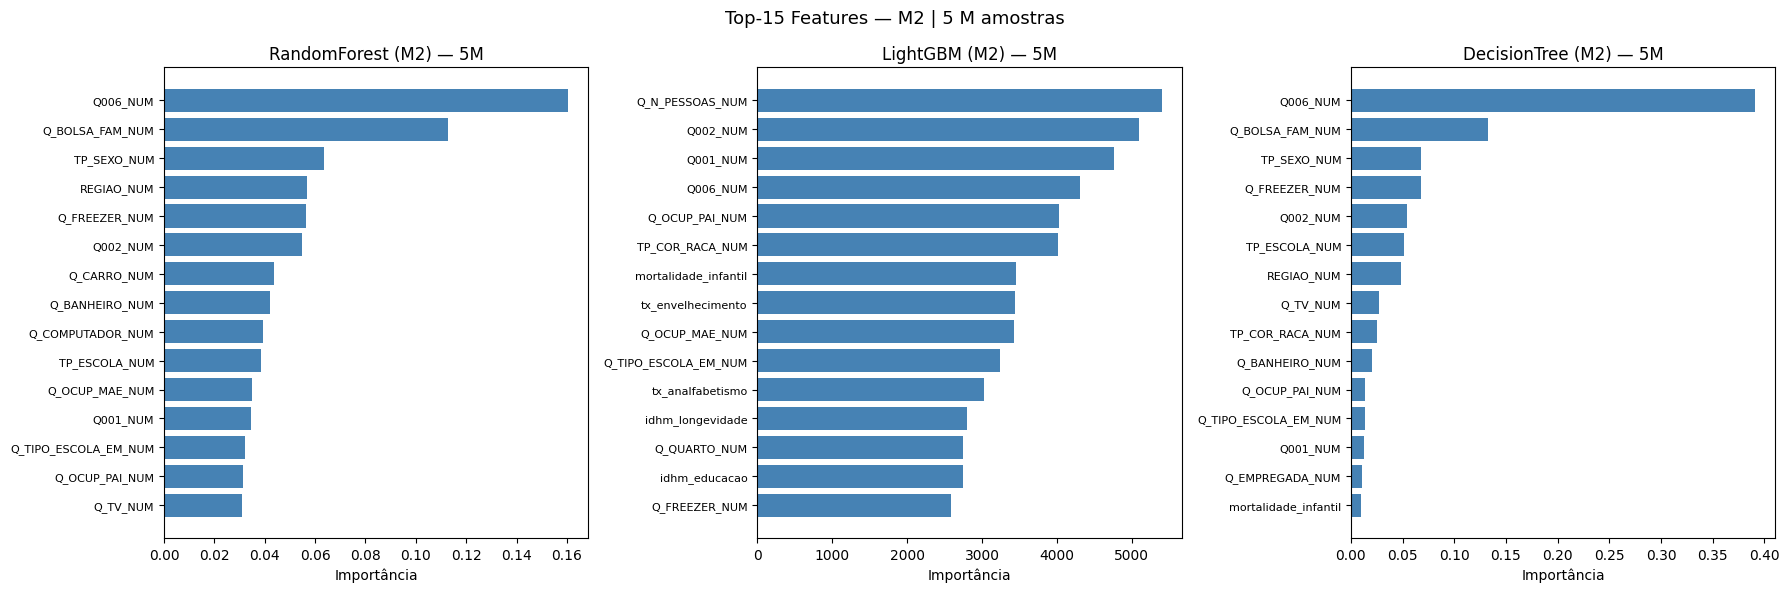

In [16]:
tree_models = ['RandomForest', 'HistGradientBoosting', 'LightGBM', 'DecisionTree']
feats = VARIANTS[best_var]

fig, axes = plt.subplots(1, min(3, len(tree_models)), figsize=(18, 6))
axes = [axes] if len(tree_models) == 1 else list(axes)
ax_idx = 0

for nome in tree_models:
    if ax_idx >= len(axes): break
    m   = all_trained.get((nome, best_var))
    if m is None: continue
    clf = m.named_steps['clf'] if hasattr(m, 'named_steps') else m
    if not hasattr(clf, 'feature_importances_'): continue
    imp = clf.feature_importances_
    ax  = axes[ax_idx]
    top = np.argsort(imp)[::-1][:15]
    ax.barh([feats[i] for i in top[::-1]], imp[top[::-1]], color='steelblue')
    ax.set_title(f'{nome} ({best_var}) — 5M')
    ax.set_xlabel('Importância')
    ax.tick_params(axis='y', labelsize=8)
    ax_idx += 1

plt.suptitle(f'Top-15 Features — {best_var} | 5 M amostras', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/feature_importances_5m.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Acurácia por região (hipótese H1)

In [17]:
REGIAO_MAP = {0: 'Norte', 1: 'Nordeste', 2: 'Centro-Oeste', 3: 'Sudeste', 4: 'Sul'}

df_ev = df_val[['REGIAO_NUM', 'FAIXA_3C']].copy()
df_ev['y_pred'] = y_pred_best
df_ev['acerto'] = (df_ev['y_pred'] == df_ev['FAIXA_3C']).astype(int)

acc_reg = (
    df_ev.dropna(subset=['REGIAO_NUM'])
    .groupby('REGIAO_NUM')['acerto']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Acurácia', 'count': 'N'})
)
acc_reg.index = acc_reg.index.map(REGIAO_MAP)
acc_reg['Acurácia'] = acc_reg['Acurácia'].apply(lambda x: f'{x:.3f}')
acc_reg['N']        = acc_reg['N'].apply(lambda x: f'{x:,}')
print(f'Acurácia por região — {best_nome} ({best_var}) | 5 M amostras | validação:')
print(acc_reg.to_string())

Acurácia por região — SVM (LinearSVC) (M2) | 5 M amostras | validação:
             Acurácia        N
REGIAO_NUM                    
Norte           0.635  162,381
Nordeste        0.579  537,742
Centro-Oeste    0.540  122,537
Sudeste         0.519  504,372
Sul             0.516  161,739


## 9. ⚠️ Conjunto de TESTE — SELADO

**Descomentar apenas na entrega final.**

In [18]:
# ── DESCOMENTE APENAS NA ENTREGA FINAL ──────────────────────────────────────
#
# X_te_best   = arrays[best_var][2]
# y_pred_test = best_model.predict(X_te_best)
# acc_test    = accuracy_score(y_test, y_pred_test)
# f1_test     = f1_score(y_test, y_pred_test, average='macro',
#                        labels=CLASS_3, zero_division=0)
# print(f'TESTE — {best_nome} ({best_var}) | 5 M amostras')
# print(f'Acurácia: {acc_test:.4f}  |  F1 Macro: {f1_test:.4f}')
# print(classification_report(y_test, y_pred_test, labels=CLASS_3, zero_division=0))
#
# ─────────────────────────────────────────────────────────────────────────────
print('Teste selado. Descomentar somente na entrega final.')

Teste selado. Descomentar somente na entrega final.
